#  CNN개념이해_MNIST

* 본 파일은 GPU 런타임으로 연결됩니다.
* 경우에 따라서는 GPU 연결이 원활하지 않을 수도 있습니다.

## 1.환경준비

### (1) 라이브러리 로딩

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random as rd
import cv2, os  # cv2 : OpenCV

from sklearn.model_selection import train_test_split
from sklearn.metrics import *

from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Input
from keras.backend import clear_session
from keras.optimizers import Adam
from keras.datasets import mnist, fashion_mnist

* 함수 만들기

In [3]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.figure(figsize=(10,6))
    plt.plot(history['loss'], label='train_err', marker = ',')
    plt.plot(history['val_loss'], label='val_err', marker = ',')
    plt.ylim(0, 1)

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (2) 데이터로딩

![](https://wikidocs.net/images/page/60324/mnist.png)

In [4]:
# 케라스 데이터셋으로 부터 mnist 불러오기
(x_train, y_train), (x_val, y_val) = mnist.load_data()

In [5]:
x_train.shape, y_train.shape

((60000, 28, 28), (60000,))

In [6]:
class_names = ['0','1','2','3','4','5','6','7','8','9']

## 2 데이터 살펴보기

* 이미지 확인하기

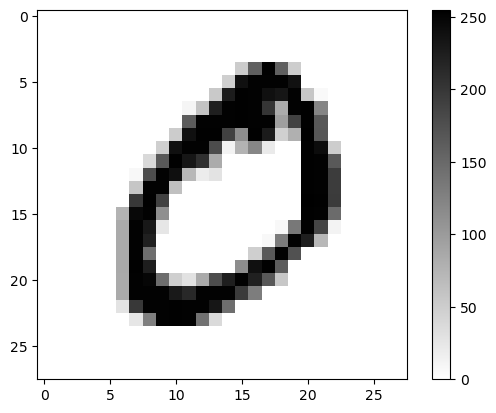

In [7]:
# 아래 숫자를 바꿔가며 화면에 그려 봅시다.
n = 1

plt.imshow(x_train[n], cmap=plt.cm.binary)
plt.colorbar()
plt.show()

* 이미지를 픽셀 값(배열 값)으로 확인하기

In [8]:
# numpy array 화면 출력시 문자열 길이 조정
np.set_printoptions(linewidth=500)
x_train[n]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  54, 227, 253, 252, 239, 233, 252

* 여러 이미지 확인하기

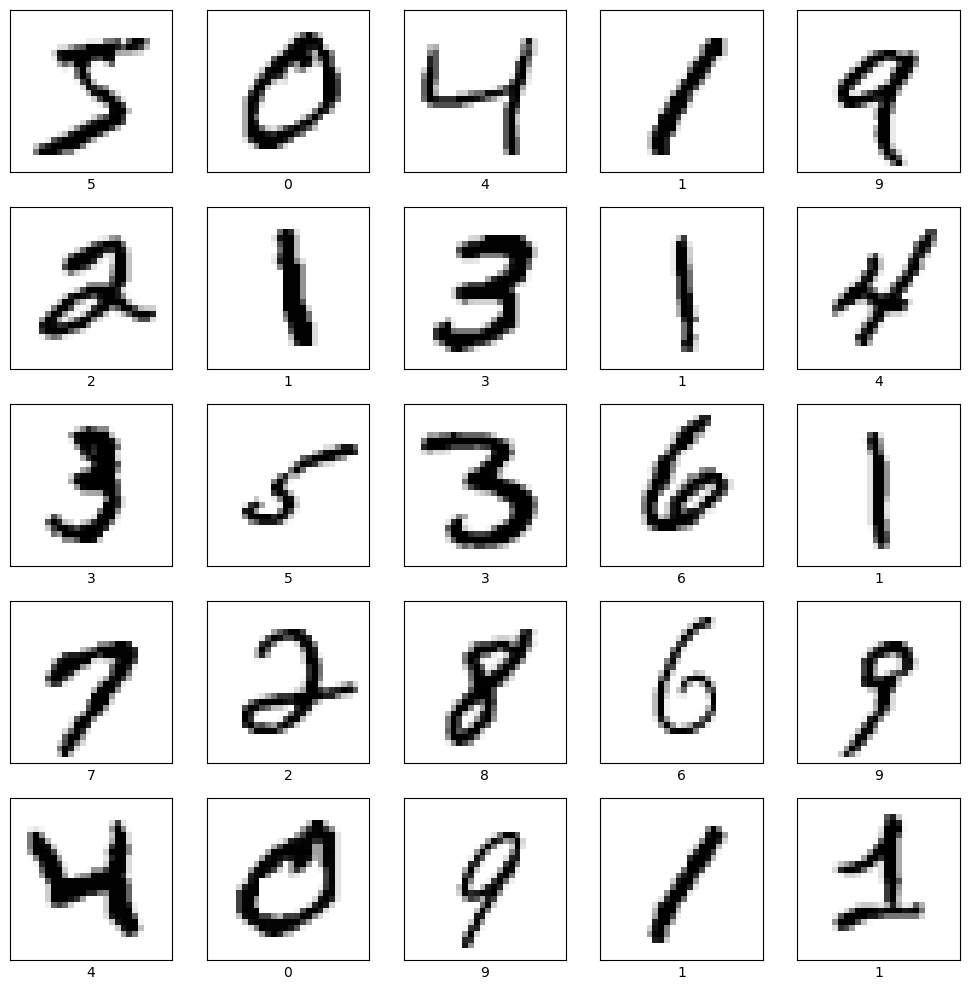

In [9]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.tight_layout()
plt.show()

## 3.데이터 준비

* CNN은 3차원 구조의 이미지(데이터셋은 4차원)를 입력해야 합니다.(input_shape)

In [10]:
x_train.shape, x_val.shape

((60000, 28, 28), (10000, 28, 28))

* reshape를 이용하여 다음과 같이 변환해 봅시다.
    * x_train.shape : (60000, 28, 28, 1)
    * x_val.shape : (10000, 28, 28, 1)

In [11]:
x_train = x_train.reshape(60000,28,28,1)
x_val = x_val.reshape(10000,28,28,1)

* Scaling : Min-Max
    * 0-255 값으로 되어 있는 데이터를 0-1사이 값으로 변환
    * x_train, x_val 그냥 255로 나누면 됨

In [12]:
x_train = x_train / 255.
x_val = x_val / 255.

## 4.CNN 기본 모델링

### (1) 모델 설계
* CNN 모델의 기본 구조
    * Conv2D  : 지역적인 특징 도출
    * MaxPooling : 요약
    * Flatten : 1차원으로 펼치기
    * Dense : Output Layer

In [18]:
clear_session()

model = Sequential([Input(shape = (28, 28, 1)),
                    Conv2D(16, kernel_size = 3, padding='same', activation='relu'),  # strides = 1(기본값,1)
                    MaxPooling2D(pool_size = 2 ),             # strides = 2(기본값이 pool_size 동일)
                    Flatten(),
                    Dense(10, activation='softmax')
])

model.summary()

model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy')

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 16)        160       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 16)       0         
 )                                                               
                                                                 
 flatten (Flatten)           (None, 3136)              0         
                                                                 
 dense (Dense)               (None, 10)                31370     
                                                                 
Total params: 31,530
Trainable params: 31,530
Non-trainable params: 0
_________________________________________________________________


### (2) 학습

In [19]:
history = model.fit(x_train, y_train, epochs = 10, validation_split=0.2).history

Epoch 1/10
1500/1500 [==============================] - 10s 2ms/step - loss: 0.2848 - val_loss: 0.1303
Epoch 2/10
1500/1500 [==============================] - 4s 2ms/step - loss: 0.1108 - val_loss: 0.0938
Epoch 3/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0813 - val_loss: 0.0781
Epoch 4/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0664 - val_loss: 0.0762
Epoch 5/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0574 - val_loss: 0.0772
Epoch 6/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0505 - val_loss: 0.0766
Epoch 7/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0439 - val_loss: 0.0704
Epoch 8/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0392 - val_loss: 0.0664
Epoch 9/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0342 - val_loss: 0.0721
Epoch 10/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.03

### (3) 학습결과 그래프

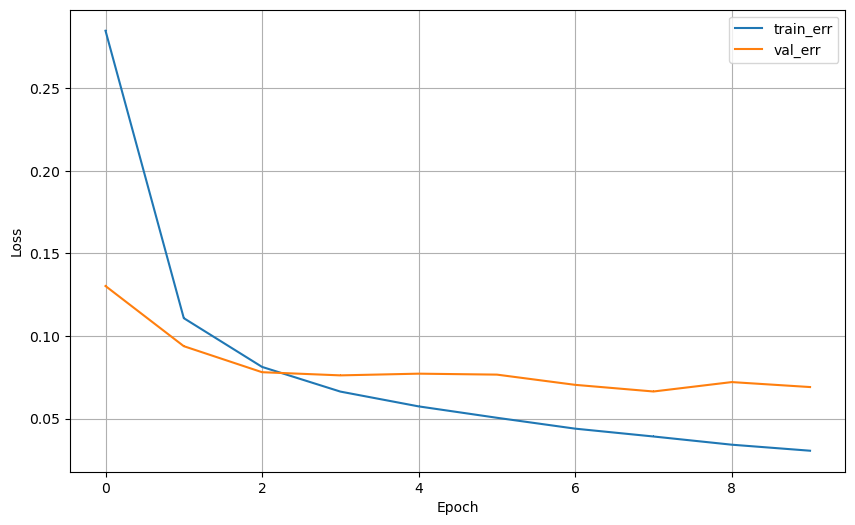

In [20]:
dl_history_plot(history)

### (4) 예측 및 평가

In [21]:
pred = model.predict(x_val)

313/313 [==============================] - 0s 1ms/step


In [ ]:
pred_1 = pred.argmax(axis=1)

In [26]:
print(accuracy_score(y_val,pred_1))
print('-'*60)
print(confusion_matrix(y_val, pred_1))
print('-'*60)
print(classification_report(y_val, pred_1))

0.9812
------------------------------------------------------------
[[ 972    0    2    2    0    1    1    1    1    0]
 [   0 1131    3    1    0    0    0    0    0    0]
 [   4    4 1012    2    1    0    1    5    2    1]
 [   2    0    2 1001    0    1    0    0    3    1]
 [   1    1    1    0  968    0    3    0    2    6]
 [   2    1    1   11    0  871    4    0    2    0]
 [   7    2    1    0    5    2  937    0    4    0]
 [   1    5   15    2    1    0    0  999    3    2]
 [   5    0    5    0    1    1    2    2  956    2]
 [   4    5    2    5   10    5    0    9    4  965]]
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      1.00      0.99      1135
           2       0.97      0.98      0.97      1032
           3       0.98      0.99      0.98      1010
           4       0.98      0.99      0.98       982
           5   

## 5.실습


### (1) 모델1
* 기본 모델링에서 다음을 조정해 봅시다.
    * Flatten 이후 Dense 레이어 추가(노드수 128)

| Layer (type) | Output Shape  | Param #   |
|---- |----|----|
| conv2d (Conv2D)  |  (None, 28, 28, 16) | 160       |
| max_pooling2d |  (None, 14, 14, 16) |      0         |
| flatten (Flatten) | (None, 3136)   |           0         |
| **dense (Dense)** |    **(None, 128)**   |            401536    |
| dense_1 (Dense) |    (None, 10)   |             1290     |

In [37]:
clear_session()

model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(16, kernel_size = 3, padding='same', activation='relu'),
    MaxPooling2D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

display(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 16)        160       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 16)       0         
 )                                                               
                                                                 
 flatten (Flatten)           (None, 3136)              0         
                                                                 
 dense (Dense)               (None, 128)               401536    
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 402,986
Trainable params: 402,986
Non-trainable params: 0
__________________________________________________

None

In [38]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy')

In [31]:
history = model.fit(x_train, y_train, epochs = 10, validation_split=0.2).history

Epoch 1/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.1838 - val_loss: 0.0856
Epoch 2/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0663 - val_loss: 0.0686
Epoch 3/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0434 - val_loss: 0.0609
Epoch 4/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0295 - val_loss: 0.0584
Epoch 5/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0196 - val_loss: 0.0612
Epoch 6/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0140 - val_loss: 0.0595
Epoch 7/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0108 - val_loss: 0.0709
Epoch 8/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0090 - val_loss: 0.0638
Epoch 9/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0077 - val_loss: 0.0872
Epoch 10/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.004

* 학습결과 그래프

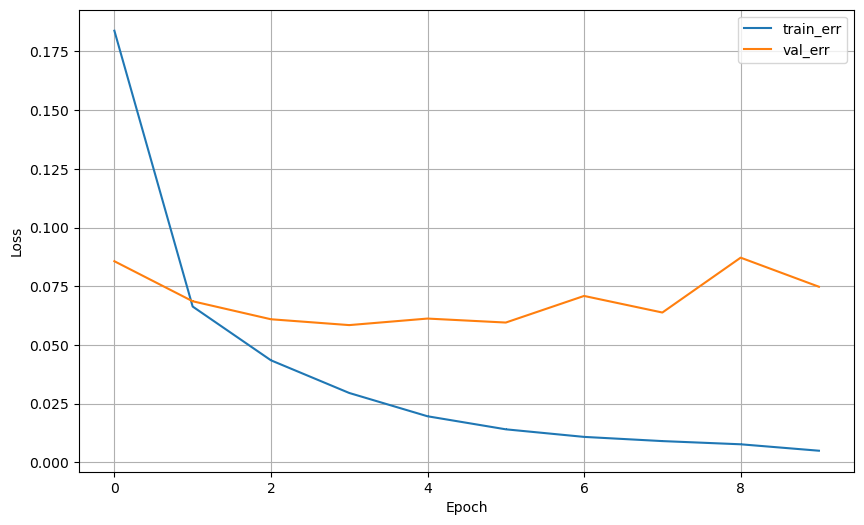

In [33]:
dl_history_plot(history)

* 예측 및 평가

In [34]:
pred = model.predict(x_val)

313/313 [==============================] - 0s 1ms/step


In [ ]:
pred_1 = pred.argmax(axis=1)

In [36]:
print(accuracy_score(y_val,pred_1))
print('-'*60)
print(confusion_matrix(y_val, pred_1))
print('-'*60)
print(classification_report(y_val, pred_1))

0.9836
------------------------------------------------------------
[[ 964    0    5    1    0    2    7    0    1    0]
 [   0 1126    4    0    0    1    3    1    0    0]
 [   1    0 1019    5    0    0    1    3    3    0]
 [   0    0    2 1000    1    7    0    0    0    0]
 [   0    0    0    0  969    0    5    1    1    6]
 [   1    0    1    5    0  881    4    0    0    0]
 [   2    2    0    0    1    3  950    0    0    0]
 [   1    0    9    5    0    0    0 1011    1    1]
 [   1    0    7   11    0    9    4    3  939    0]
 [   0    1    1    6    8   10    0    4    2  977]]
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.97      0.99      0.98      1032
           3       0.97      0.99      0.98      1010
           4       0.99      0.99      0.99       982
           5   

### (2) 모델2
* 모델1에 이어서 다음을 조정해 봅시다.
    * Convnet의 커널 수를 32로 늘려 봅시다.

| Layer (type) | Output Shape  | Param #   |
|---- |----|----|
| conv2d (Conv2D)  |  (None, 28, 28, **32**) | 320       |
| max_pooling2d |  (None, 14, 14, 32) |      0         |
| flatten (Flatten) | (None, 6272)   |           0         |
| dense (Dense) |    (None, 128)   |            802944        |
| dense_1 (Dense) |    (None, 10)   |             1290     |

In [39]:
clear_session()

model = Sequential([
    Input(shape=(28, 28, 1)),                   
    Conv2D(32, kernel_size=3, padding='same', activation='relu'), 
    MaxPooling2D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                                 
 flatten (Flatten)           (None, 6272)              0         
                                                                 
 dense (Dense)               (None, 128)               802944    
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 804,554
Trainable params: 804,554
Non-trainable params: 0
__________________________________________________

In [40]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy')

In [41]:
history = model.fit(x_train, y_train, epochs = 10, validation_split=0.2).history

Epoch 1/10
1500/1500 [==============================] - 4s 2ms/step - loss: 0.1740 - val_loss: 0.0828
Epoch 2/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0593 - val_loss: 0.0578
Epoch 3/10
1500/1500 [==============================] - 4s 2ms/step - loss: 0.0370 - val_loss: 0.0534
Epoch 4/10
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0249 - val_loss: 0.0576
Epoch 5/10
1500/1500 [==============================] - 4s 2ms/step - loss: 0.0162 - val_loss: 0.0586
Epoch 6/10
1500/1500 [==============================] - 4s 2ms/step - loss: 0.0117 - val_loss: 0.0646
Epoch 7/10
1500/1500 [==============================] - 4s 2ms/step - loss: 0.0095 - val_loss: 0.0595
Epoch 8/10
1500/1500 [==============================] - 4s 2ms/step - loss: 0.0075 - val_loss: 0.0951
Epoch 9/10
1500/1500 [==============================] - 4s 2ms/step - loss: 0.0054 - val_loss: 0.0690
Epoch 10/10
1500/1500 [==============================] - 4s 2ms/step - loss: 0.006

* 학습결과 그래프

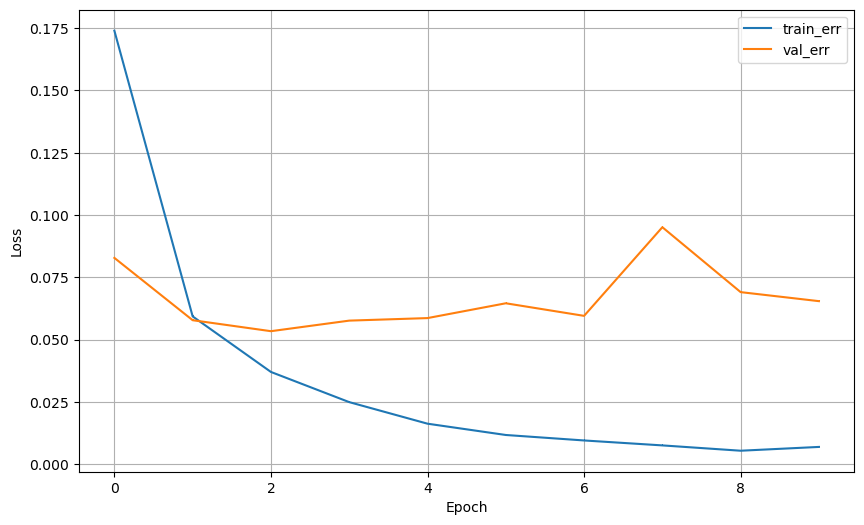

In [42]:
dl_history_plot(history)

* 예측 및 평가

In [43]:
pred = model.predict(x_val)

313/313 [==============================] - 0s 1ms/step


In [ ]:
pred_1 = pred.argmax(axis=1)

In [46]:
print(accuracy_score(y_val,pred_1))
print('-'*60)
print(confusion_matrix(y_val, pred_1))
print('-'*60)
print(classification_report(y_val, pred_1))

0.9886
------------------------------------------------------------
[[ 976    0    1    1    0    0    1    0    1    0]
 [   0 1129    1    0    0    1    3    1    0    0]
 [   1    1 1016    2    0    0    1    5    5    1]
 [   0    0    4  996    0    5    1    0    2    2]
 [   0    0    0    0  975    0    2    0    0    5]
 [   2    1    0    6    0  879    4    0    0    0]
 [   1    2    0    1    1    2  950    0    1    0]
 [   1    0    7    1    0    0    0 1015    1    3]
 [   3    0    0    0    0    1    2    2  962    4]
 [   1    1    1    1    6    2    0    5    4  988]]
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      0.99      1.00      1135
           2       0.99      0.98      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5   

### (3) 모델3
* 모델2에 이어서, 아래 그림을 보고, 빠진 부분을 추가하시오.

![](https://github.com/DA4BAM/image/blob/main/cnn_mnist3.png?raw=true)

In [13]:
clear_session()

model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, padding='same', kernel_size=3, strides=1, activation='relu'),
	MaxPooling2D(pool_size=2),
    Conv2D(64, padding='same', kernel_size=3, strides=1, activation='relu'),
    MaxPooling2D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 7, 64)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 3136)              0         
                                                                 
 dense (Dense)               (None, 128)               4

In [14]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy')

In [15]:
history = model.fit(x_train, y_train, epochs = 10, validation_split=0.2).history

Epoch 1/10
1500/1500 [==============================] - 8s 3ms/step - loss: 0.1357 - val_loss: 0.0596
Epoch 2/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0447 - val_loss: 0.0482
Epoch 3/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0291 - val_loss: 0.0408
Epoch 4/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0211 - val_loss: 0.0380
Epoch 5/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0157 - val_loss: 0.0452
Epoch 6/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0114 - val_loss: 0.0491
Epoch 7/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0099 - val_loss: 0.0468
Epoch 8/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0076 - val_loss: 0.0451
Epoch 9/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0068 - val_loss: 0.0500
Epoch 10/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.005

* 학습결과 그래프

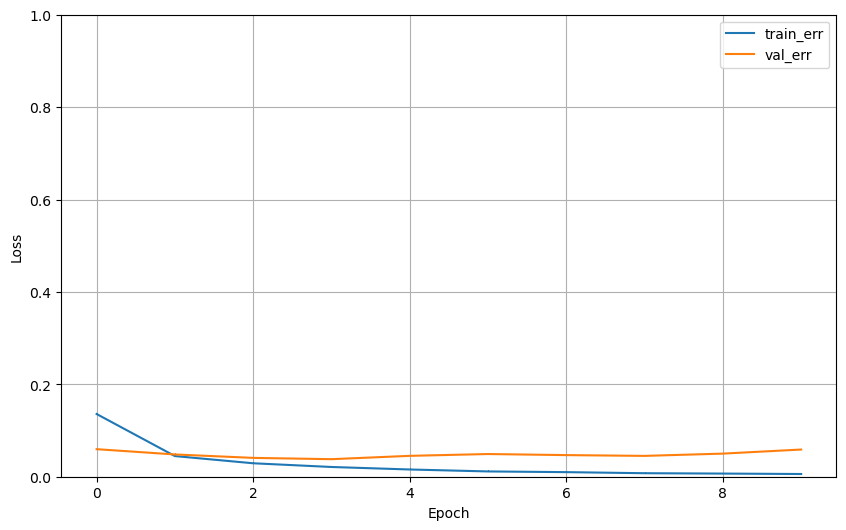

In [16]:
dl_history_plot(history)

* 예측 및 평가

In [17]:
pred = model.predict(x_val)

313/313 [==============================] - 0s 1ms/step


In [18]:
pred_1 = pred.argmax(axis=1)

In [19]:
print(accuracy_score(y_val,pred_1))
print('-'*60)
print(confusion_matrix(y_val, pred_1))
print('-'*60)
print(classification_report(y_val, pred_1))

0.9898
------------------------------------------------------------
[[ 977    0    0    0    0    1    0    1    1    0]
 [   0 1131    0    2    0    0    0    0    2    0]
 [   1    3 1011    3    2    0    0    8    4    0]
 [   0    0    0 1005    0    3    0    0    1    1]
 [   0    0    0    0  978    0    0    0    0    4]
 [   0    0    0    8    0  882    0    0    0    2]
 [   6    1    0    1    3    8  936    0    3    0]
 [   0    4    1    1    0    1    0 1017    1    3]
 [   2    0    1    4    0    1    1    0  962    3]
 [   1    1    0    0    4    2    0    1    1  999]]
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       1.00      0.98      0.99      1032
           3       0.98      1.00      0.99      1010
           4       0.99      1.00      0.99       982
           5   

## 6.틀린그림 찾아보기
* 모델3의 결과에서 틀린 그림을 살펴 봅시다.
* 아래코드는 이해하기보다는 그냥 사용하기 바랍니다.

In [20]:
idx = (y_val != pred_1)
x_val_wr = x_val[idx]
y_val_wr = y_val[idx]
pred_wr = pred_1[idx]

x_val_wr = x_val_wr.reshape(-1,28,28)
print(x_val_wr.shape)

(102, 28, 28)


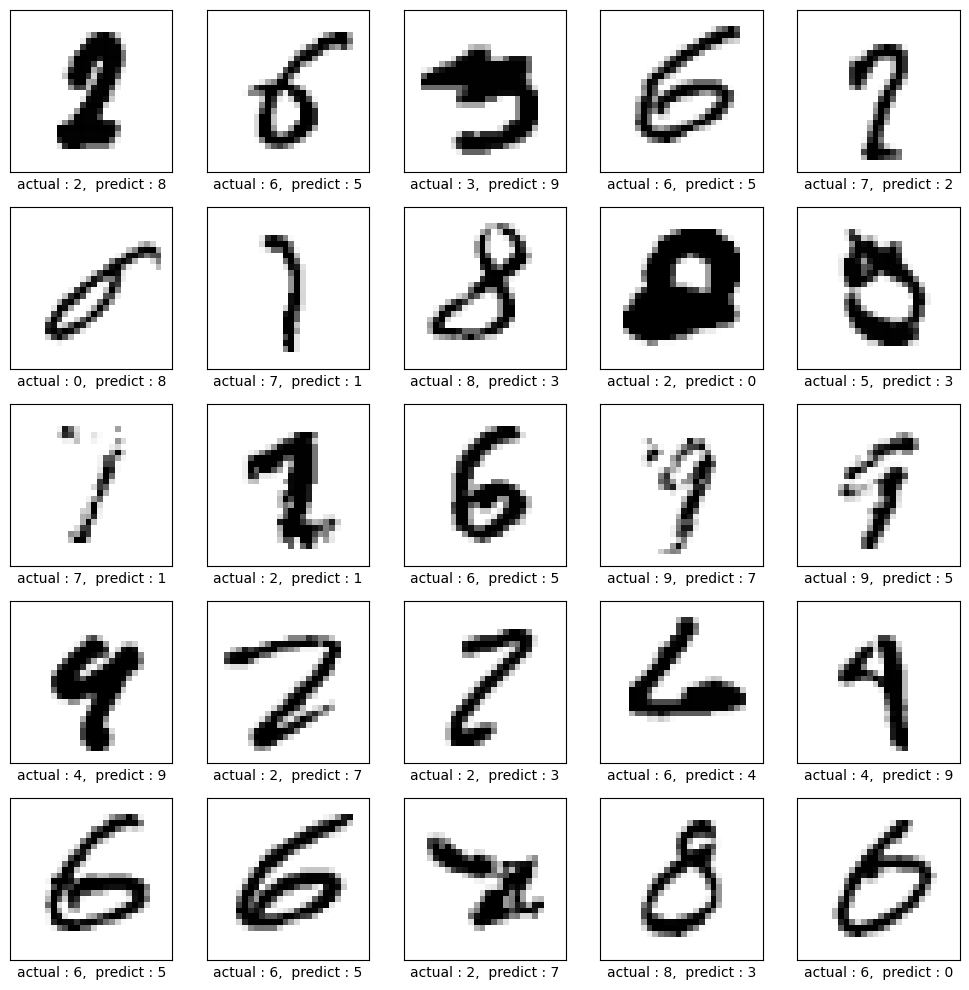

In [21]:
idx = rd.sample(range(x_val_wr.shape[0]),25)
x_temp = x_val_wr[idx]
y_temp = y_val_wr[idx]
p_temp = pred_wr[idx]

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_temp[i], cmap=plt.cm.binary)
    plt.xlabel(f'actual : {y_temp[i]},  predict : {p_temp[i]}')
plt.tight_layout()
plt.show()

## 7.진짜 손글씨로 예측해 봅시다.

* 이미지 처리를 위한 라이브러리와 함수 불러오기

In [22]:
import cv2

* 그림판에서 그린 손글씨를 업로드 합니다.

In [ ]:
path = './data/'
num = '9'
ext = '.png'
img = cv2.imread(path + num + ext, cv2.IMREAD_GRAYSCALE)

In [35]:
# 파일 열기 : 아래 파일 이름은 여러분의 파일로 수정합니다.
if img is None:
    raise FileNotFoundError("이미지 파일을 찾을 수 없습니다. 경로를 확인하세요.")

# 이미지 표시
cv2.imshow('Original Image', img)
cv2.waitKey(0)
cv2.destroyAllWindows()
print("원본 이미지 shape:", img.shape)

원본 이미지 shape: (28, 28)


* 이미지 크기를 28, 28, 1 로 맞추기

In [36]:
# 크기 조절하기
img = cv2.resize(255 - img, (28, 28))
print("변환된 이미지 shape:", img.shape)
cv2.imshow('Resized Image (28x28, Inverted)', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

변환된 이미지 shape: (28, 28)


* 예측하기

In [37]:
# 입력데이터 형식을 갖추기
test_num = img.reshape(1,28,28,1)

# 예측하기
pred = model.predict(test_num)
pred_1 = pred.argmax(axis=1)
print(pred_1)

1/1 [==============================] - 0s 15ms/step
[9]


In [38]:
pred

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]], dtype=float32)

In [39]:
path = './data/'
ext = '.png'

for num in range(10):
    # 이미지 불러오기
    img = cv2.imread(path + str(num) + ext, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"[경고] {num}.png 파일을 찾을 수 없습니다.")
        continue

    # 색 반전 및 크기 조정
    img = cv2.resize(255 - img, (28, 28))

    # CNN 입력 형식 맞추기
    test_num = img.reshape(1, 28, 28, 1).astype('float32') / 255.0

    # 예측 수행
    pred = model.predict(test_num, verbose=0)
    pred_label = np.argmax(pred)

    # 결과 출력
    print(f"실제 숫자: {num} | 예측 숫자: {pred_label}")

실제 숫자: 0 | 예측 숫자: 0
실제 숫자: 1 | 예측 숫자: 0
실제 숫자: 2 | 예측 숫자: 2
실제 숫자: 3 | 예측 숫자: 3
실제 숫자: 4 | 예측 숫자: 4
실제 숫자: 5 | 예측 숫자: 5
실제 숫자: 6 | 예측 숫자: 5
실제 숫자: 7 | 예측 숫자: 7
실제 숫자: 8 | 예측 숫자: 8
실제 숫자: 9 | 예측 숫자: 9
